# AI Trade Share Analysis

Visualize the share of AI-related trade relative to total trade for 2023-2025.

In [3]:
import pandas as pd             # data package
import matplotlib.pyplot as plt # graphics 
import datetime as dt
import numpy as np

In [4]:
matlist = pd.read_csv('hs10_classification_final.csv')

# matlist = pd.read_csv('hs10_datacenter_relevance.csv')

# Convert to category
matlist['relevance'] = matlist['relevance'].astype('category')

# Or specify order if needed (e.g., for sorting/comparisons)
matlist['relevance'] = pd.Categorical(
    matlist['relevance'], 
    categories=['Low', 'Medium', 'High'], 
    ordered=True
)

matlist.rename(columns={'hs10_code': 'HS10'}, inplace=True)

In [5]:
matlist.head()

,relevance,confidence,primary_category,specific_use,reasoning,HS10,description
0,Low,100,Not_DC_Related,Not applicable to data center operations,Live purebred breeding horses are livestock an...,101210010,"HORSES, LIVE, PUREBRED BREEDING MALE"
1,Low,100,Not_DC_Related,Not applicable to data center construction or ...,Live purebred breeding horses are livestock an...,101210020,"HORSES, LIVE, PUREBRED BREEDING FEMALE"
2,Low,100,Not_DC_Related,Not applicable to data center operations,Live horses for slaughter are livestock/agricu...,101290010,"HORSES, LIVE, IMPORTED FOR IMMEDIATE SLAUGHTER"
3,Low,100,Not_DC_Related,Not applicable to data center construction or ...,Live horses are livestock animals with no appl...,101290090,"HORSES, LIVE, NESOI"
4,Low,100,Not_DC_Related,No application in data center construction or ...,Live animals (asses/donkeys) have no role in A...,101300000,"ASSES, LIVE"


In [7]:
df = pd.read_parquet('TOTALdata-current.parquet')

df.rename(columns={'I_COMMODITY': 'HS10'}, inplace=True)

df["HS2"] = df["HS10"].str[0:2]

df["HS10"] = df["HS10"].astype('int64')

df.time = pd.to_datetime(df.time, format="%Y-%m")

df["imports"] = df["CON_VAL_MO"].astype(float)

df["duty"] = df["CAL_DUT_MO"].astype(float)

# Remove volatile/special HS2 categories
# These categories have prices that are either:
# - Extremely volatile (oil, precious metals)
# - Lumpy/irregular (aircraft)
# - Unreliable/special (pharmaceuticals, special provisions)
excluded_hs2 = ["27", "71", "98", "99"]
df = df[~df["HS2"].isin(excluded_hs2)]

In [8]:
# Merge Relevance category from matlist onto df
df = df.merge(matlist[['HS10', 'relevance']], on='HS10', how='left')

In [9]:
grp = df.groupby(['relevance', 'time'], observed=True)

grp_sum = grp[['imports']].sum().reset_index()

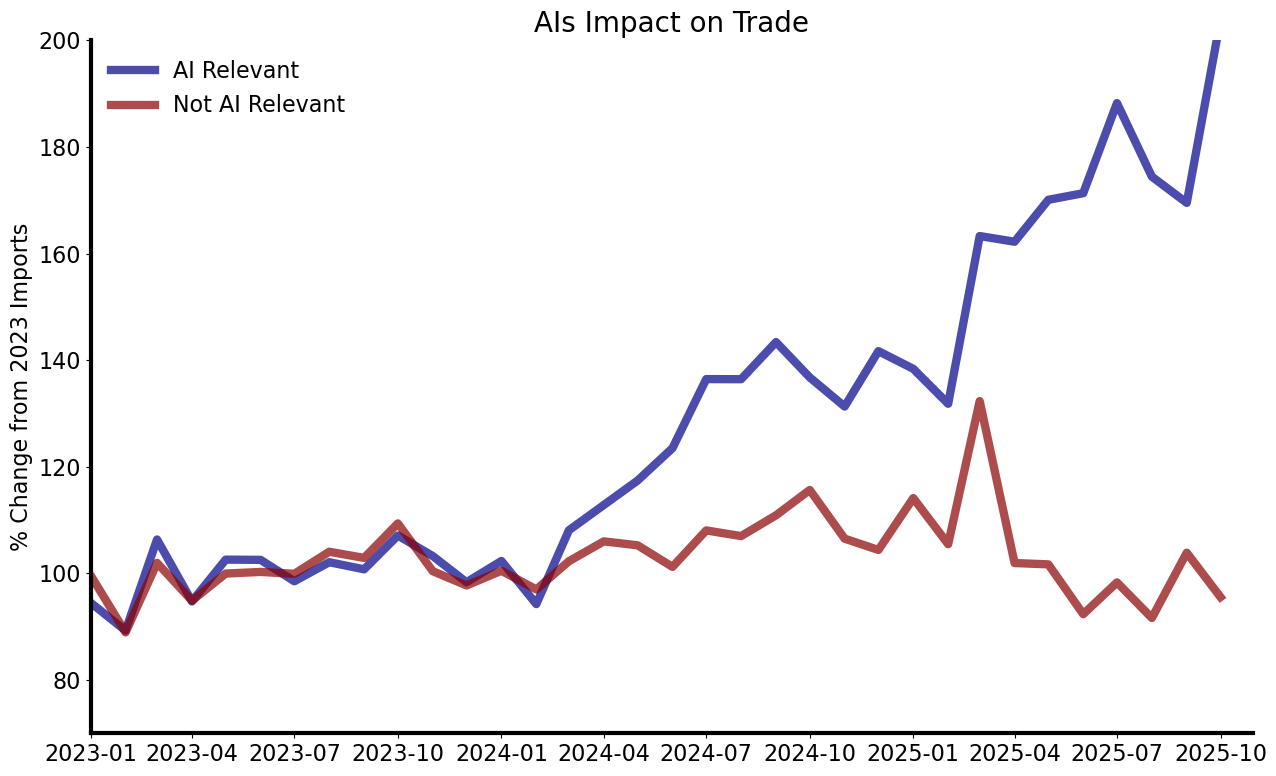

In [10]:
fig, ax = plt.subplots(figsize = (15,9))

foo = grp_sum[grp_sum['relevance']=='High'].copy()
foo.set_index('time', inplace=True)
ax.plot(foo.index, 100*(12*foo["imports"] / foo["imports"].loc["2023"].sum()) , 
        color = "darkblue", alpha = 0.7, linewidth = 6, label='AI Relevant')


# foo2 = grp_sum[grp_sum['relevance']=='Medium'].copy()
# foo2.set_index('time', inplace=True)
# ax.plot(foo2.index, 100*(12*foo2["imports"] / foo2["imports"].loc["2023"].sum()) ,
#          color = "black", alpha = 0.7, linewidth = 5, label='Not AI Relevant')

foo3 = grp_sum[grp_sum['relevance']=='Low'].copy()
foo3.set_index('time', inplace=True)
ax.plot(foo3.index, 100*(12*foo3["imports"] / foo3["imports"].loc["2023"].sum()) ,
         color = "darkred", alpha = 0.7, linewidth = 6, label='Not AI Relevant')

# # Shade between lines after 2024-01
# cutoff_date = dt.datetime(2024, 1, 1)
# mask = foo.index >= cutoff_date
# ax.fill_between(
#     foo.index[mask], 
#     100*(12*foo["imports"][mask] / foo["imports"].loc["2023"].sum() - 1.0),
#     100*(12*foo2["imports"][mask] / foo2["imports"].loc["2023"].sum() - 1.0),
#     alpha=0.3, 
#     color='gray'
# )


ax.set_title("AIs Impact on Trade", fontsize = 20)

ax.set_xlim([dt.datetime(2023,1,1), dt.datetime(2025,10,30)])

ax.set_ylim(70,200)

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

ax.set_ylabel("% Change from 2023 Imports", fontsize=16)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(3)
ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,
    frameon=False,
    loc='upper left',
    ncol=1
)

# plt.savefig(figfile+"canada-tariffs.png", bbox_inches = "tight")
# plt.savefig(figfile+"canada-tariffs.pdf", bbox_inches = "tight")

plt.show()

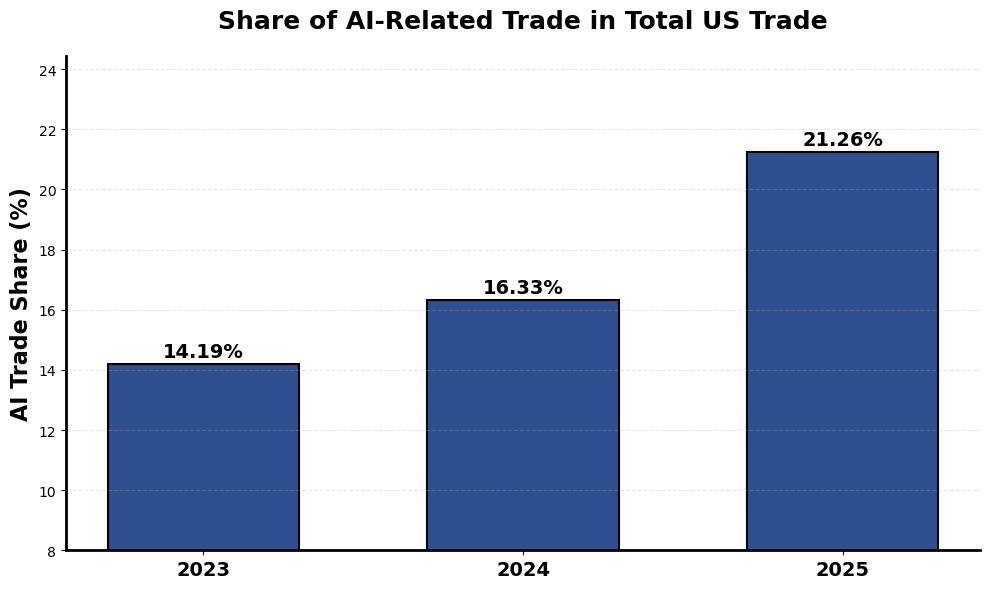


AI Trade Share:
  2023: 14.19%
  2024: 16.33%
  2025: 21.26%

Growth: 7.07 percentage points


In [ ]:
# Calculate AI trade share for each year (2023-2025)
years = [2023, 2024, 2025]
ai_shares = []

foo = grp_sum[grp_sum['relevance']=='High'].copy()
foo.set_index("time", inplace=True)
df.set_index("time", inplace=True)

for year in years:
    year_str = str(year)
    total_trade = df.imports.loc[year_str].sum()
    ai_trade = foo.imports.loc[year_str].sum()
    ai_share = (ai_trade / total_trade) * 100
    ai_shares.append(ai_share)

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(years, ai_shares, color='#2E5090', edgecolor='black', linewidth=1.5, width=0.6)

# Add value labels on bars
for i, (year, share) in enumerate(zip(years, ai_shares)):
    ax.text(year, share + 0.1, f'{share:.2f}%', 
            ha='center', va='bottom', fontsize=14, fontweight='bold')

# Formatting
# ax.set_xlabel('Year', fontsize=16, fontweight='bold')
ax.set_ylabel('AI Trade Share (%)', fontsize=16, fontweight='bold')
ax.set_title('Share of AI-Related Trade in Total US Trade', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(years)
ax.set_ylim(8, max(ai_shares) * 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Make x-tick labels bold and larger
ax.tick_params(axis='x', labelsize=14)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout()
plt.show()

print(f"\nAI Trade Share:")
for year, share in zip(years, ai_shares):
    print(f"  {year}: {share:.2f}%")
print(f"\nGrowth: {ai_shares[-1] - ai_shares[0]:.2f} percentage points")